What do your blood sugars tell you?
📖 Background
Diabetes mellitus remains a global health issue, causing several thousand people to die each day from this single condition. Finding and avoiding diabetes in the earlier stages can help reduce the risk of serious health issues such as circulatory system diseases, kidney malfunction, and vision loss. This competition involves developing a predictive model for effectively detecting potential Diabetes cases, ideally, before commencing preventive treatment.

💾 The data
The dataset contains diagnostic measurements that are associated with diabetes, which were collected from a population of Pima Indian women. The data includes various medical and demographic attributes, making it a well-rounded resource for predictive modeling.

The columns and Data Types are as follows:

Pregnancies Type: Numerical (Continuous) Description: Number of times the patient has been pregnant.

Glucose Type: Numerical (Continuous) Description: Plasma glucose concentration a 2 hours in an oral glucose tolerance test.

BloodPressure Type: Numerical (Continuous) Description: Diastolic blood pressure (mm Hg).

SkinThickness Type: Numerical (Continuous) Description: Triceps skinfold thickness (mm).

Insulin Type: Numerical (Continuous) Description: 2-Hour serum insulin (mu U/ml).

BMI Type: Numerical (Continuous) Description: Body mass index (weight in kg/(height in m)^2).

DiabetesPedigreeFunction Type: Numerical (Continuous) Description: A function that represents the likelihood of diabetes based on family history.

Age Type: Numerical (Continuous) Description: Age of the patient in years.

Outcome Type: Categorical (Binary) Description: Class variable (0 or 1) indicating whether the patient is diagnosed with diabetes. 1 = Yes, 0 = No.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
corr = data.corr()

In [11]:
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [13]:
import seaborn as sns

<Axes: >

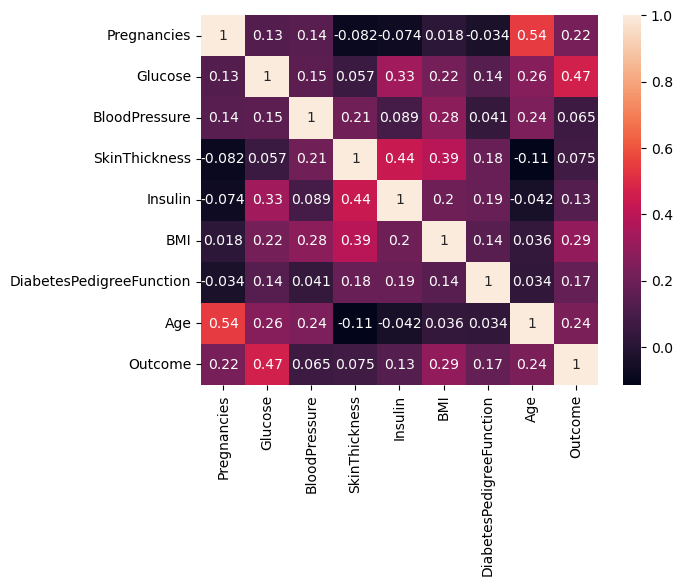

In [17]:
sns.heatmap(corr,annot=True)

#### DATA PREPROCESSING

In [3]:
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [7]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
data['Outcome'] = data['Outcome'].astype('category')

#### VISUALIZING THE DATA

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

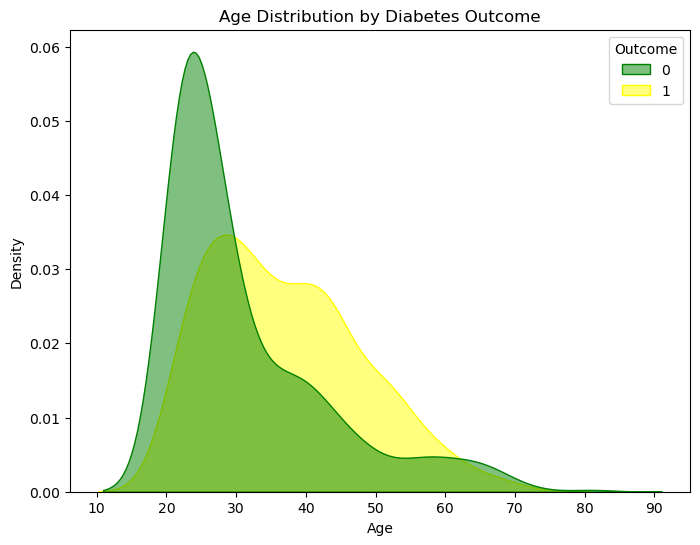

In [14]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=data, x='Age', hue='Outcome', fill=True, common_norm=False, palette=["green", "yellow"], alpha=0.5)
plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

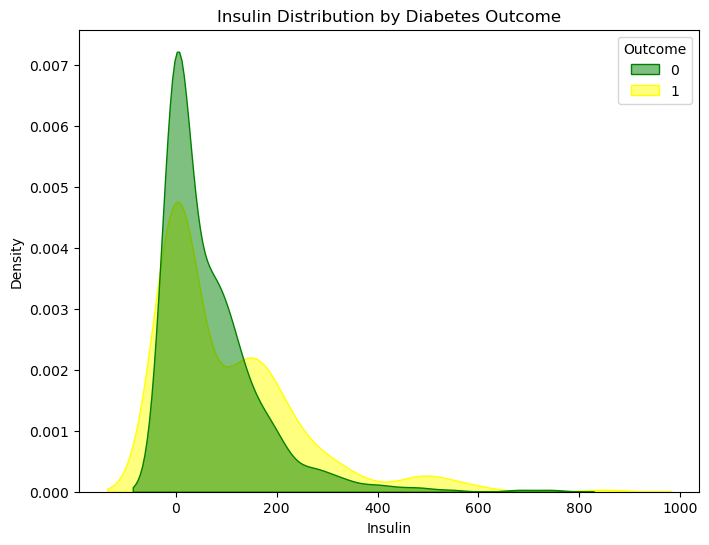

In [15]:
# Density plot of Age by Outcome
plt.figure(figsize=(8, 6))
sns.kdeplot(data=data, x='Insulin', hue='Outcome', fill=True, common_norm=False, palette=["green", "yellow"], alpha=0.5)
plt.title("Insulin Distribution by Diabetes Outcome")
plt.xlabel("Insulin")
plt.ylabel("Density")
plt.show()

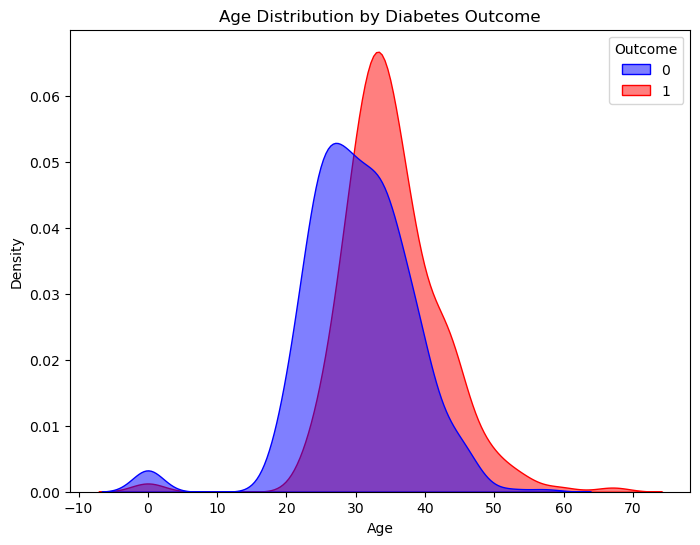

In [16]:
# Density plot of Age by Outcome
plt.figure(figsize=(8, 6))
sns.kdeplot(data=data, x='BMI', hue='Outcome', fill=True, common_norm=False, palette=["blue", "red"], alpha=0.5)
plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

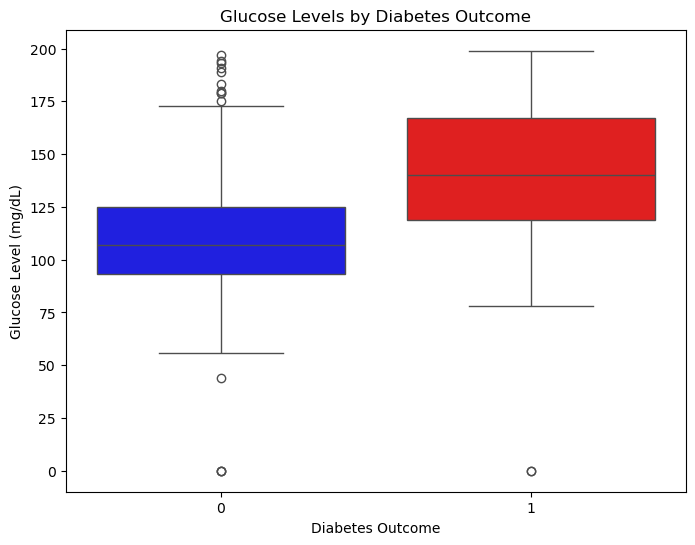

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Outcome', y='Glucose', data=data, palette=["blue", "red"])
plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Glucose Level (mg/dL)")
plt.show()

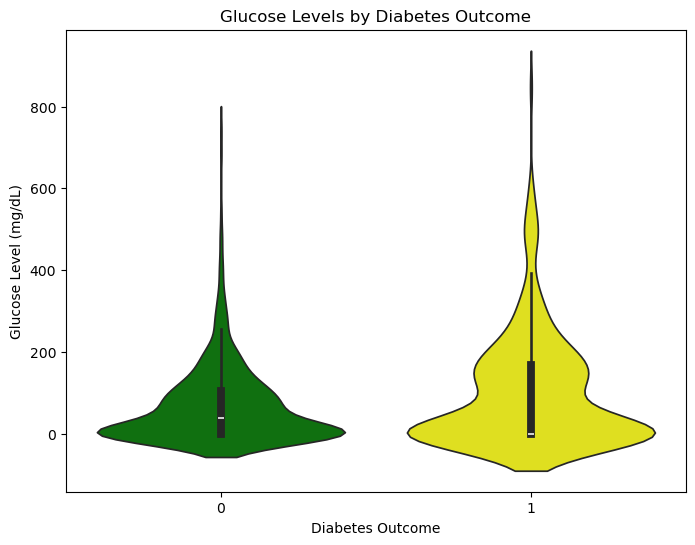

In [18]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Outcome', y='Insulin', data=data, palette=["green", "yellow"])
plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Glucose Level (mg/dL)")
plt.show()

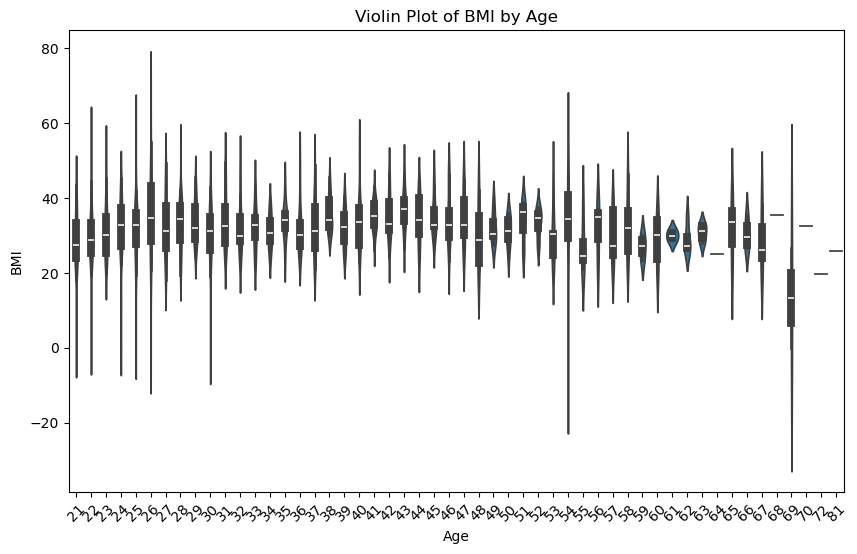

In [19]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Age', y='BMI', data=data)
plt.title('Violin Plot of BMI by Age')
plt.xticks(rotation=45)  
plt.show()


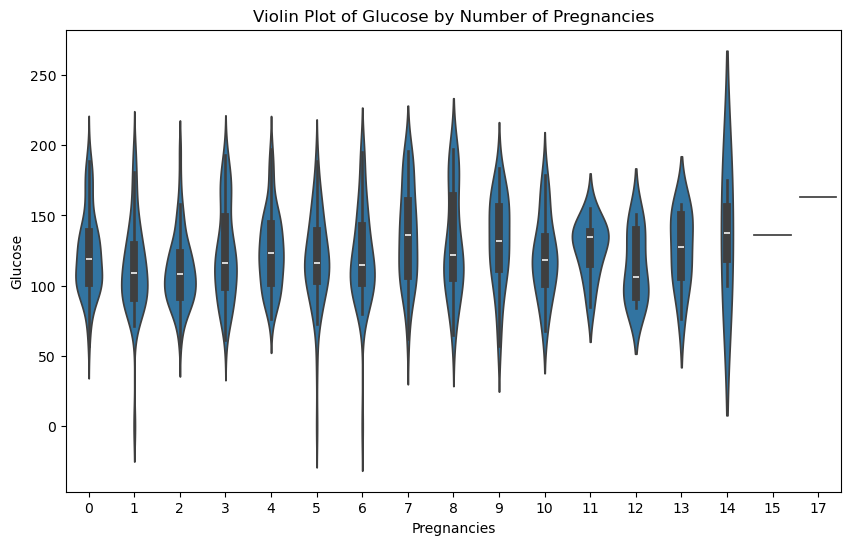

In [20]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Pregnancies', y='Glucose', data=data)
plt.title('Violin Plot of Glucose by Number of Pregnancies')
plt.show()


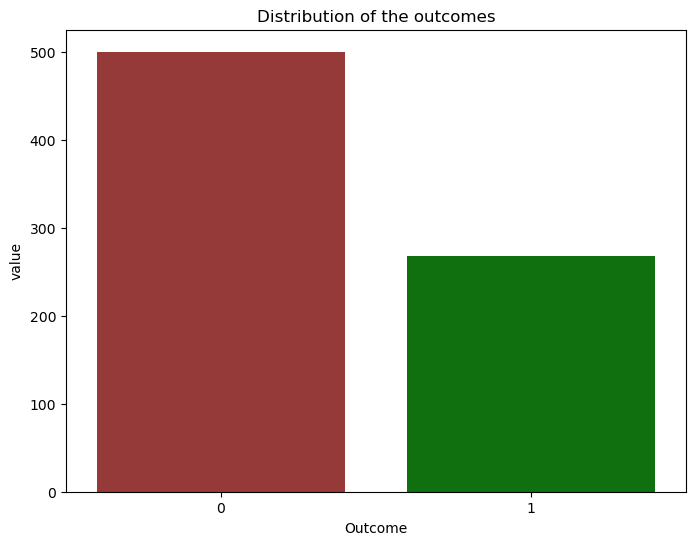

In [21]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Outcome',data=data,palette=["brown", "green"])
plt.title("Distribution of the outcomes")
plt.xlabel("Outcome")
plt.ylabel("value")
plt.show()

In [115]:
# Create Age groups
data['AgeGroup'] = pd.cut(data['Age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20-29', '30-39', '40-49', '50-59', '60-69', '70-79'])

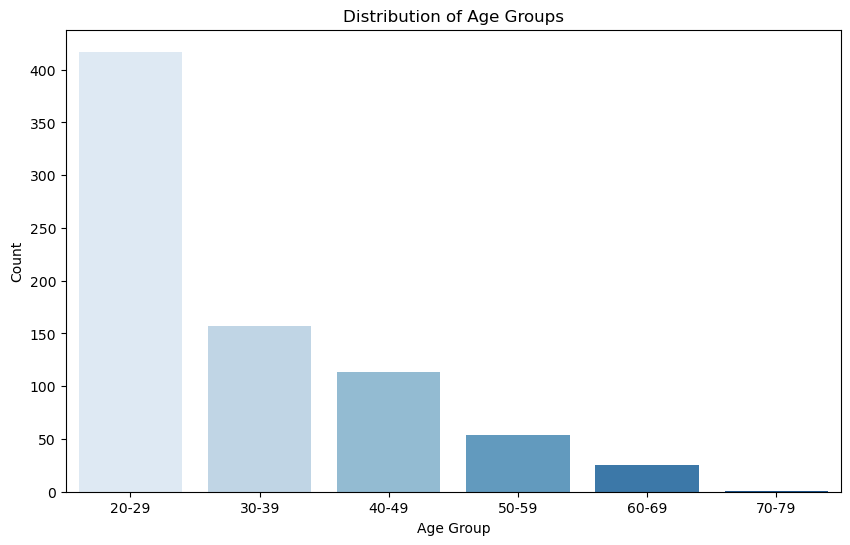

In [119]:
# Plot Age Groups
plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', data=data, palette='Blues')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

In [109]:
# BMI Categories
data['BMICategory'] = pd.cut(data['BMI'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

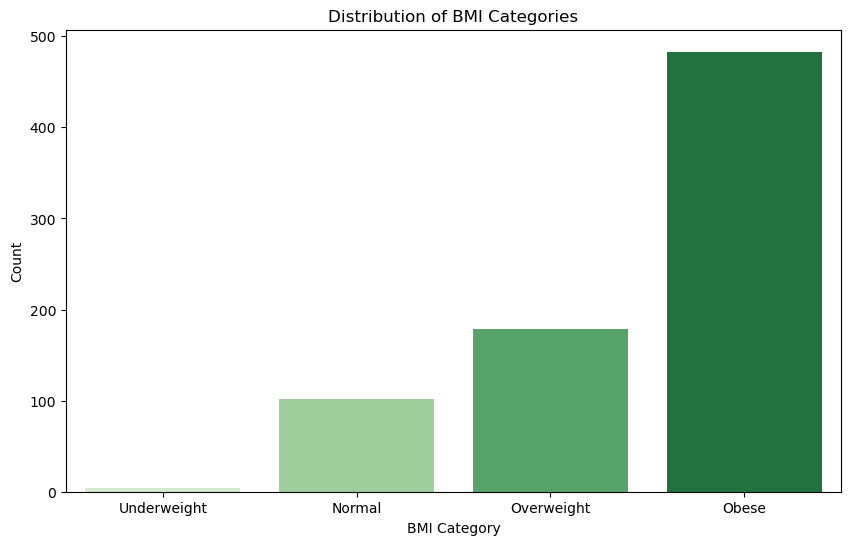

In [113]:
# Plot BMI Categories
plt.figure(figsize=(10, 6))
sns.countplot(x='BMICategory', data=data, palette='Greens')
plt.title('Distribution of BMI Categories')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()


In [105]:
# Pregnancy Groups
data['PregnancyGroup'] = pd.cut(data['Pregnancies'], bins=[-1, 0, 2, 6, np.inf], labels=['None', 'Few', 'Moderate', 'Many'])

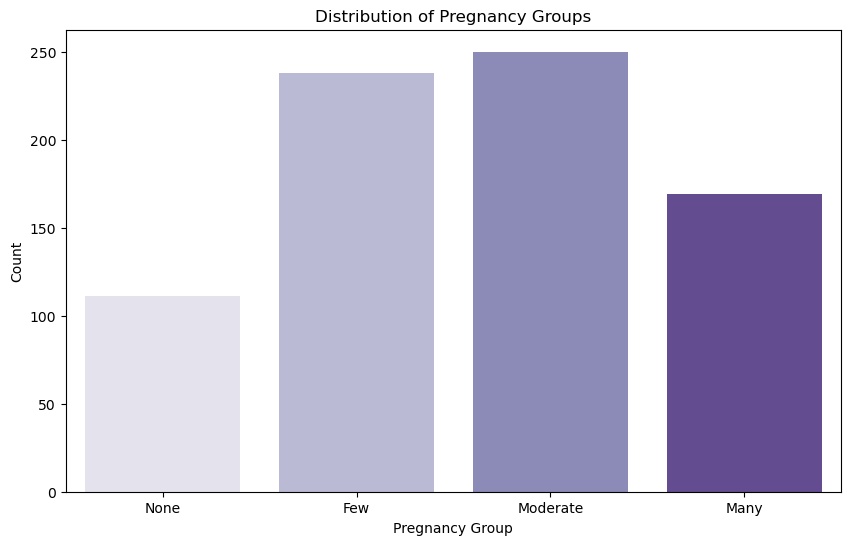

In [107]:
# Plot Pregnancy Groups
plt.figure(figsize=(10, 6))
sns.countplot(x='PregnancyGroup', data=data, palette='Purples')
plt.title('Distribution of Pregnancy Groups')
plt.xlabel('Pregnancy Group')
plt.ylabel('Count')
plt.show()


MODEL BUILDING

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

In [131]:
from sklearn.preprocessing import StandardScaler

# Standardize continuous variables
scaler = StandardScaler()
continuous_vars = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
data[continuous_vars] = scaler.fit_transform(data[continuous_vars])


In [139]:
data.dtypes

Pregnancies                    int64
Glucose                      float64
BloodPressure                float64
SkinThickness                float64
Insulin                      float64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                          float64
Outcome                     category
AgeGroup                    category
BMICategory                 category
PregnancyGroup              category
dtype: object

In [103]:
# Define features and target variable
X = data.drop(columns='Outcome')
y = data['Outcome']



# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=666,stratify = y)

In [149]:
# One-hot encode the categorical columns
categorical_cols = ['AgeGroup', 'BMICategory', 'PregnancyGroup']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [105]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [107]:
# Initialize the Logistic Regression model
logreg = LogisticRegression(max_iter=200)

# Fit the model on the training data
logreg.fit(X_train, y_train)


LogisticRegression(max_iter=200)

In [109]:
from sklearn.metrics import confusion_matrix

# Predict on the test set
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(class_report)


Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       125
           1       0.74      0.58      0.65        67

    accuracy                           0.78       192
   macro avg       0.77      0.74      0.75       192
weighted avg       0.78      0.78      0.77       192



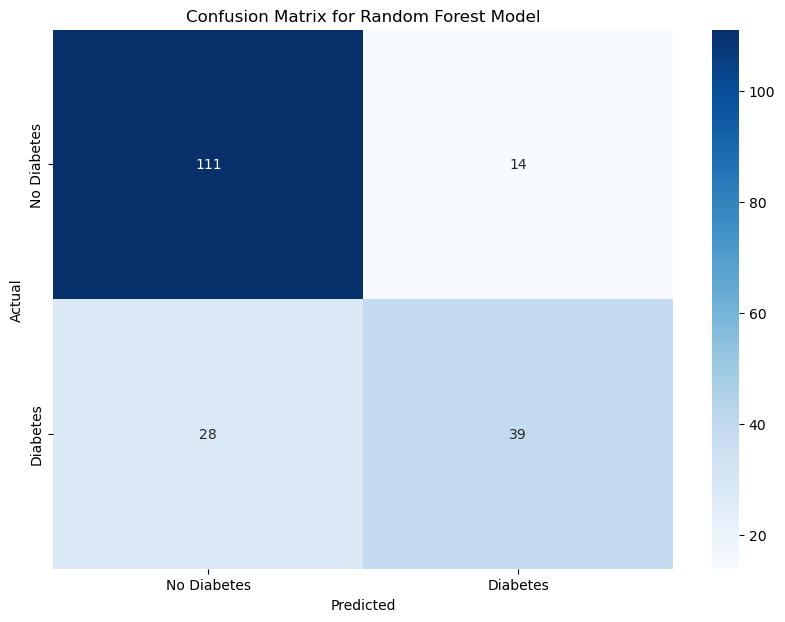

In [73]:
# Predict on the test set
y_pred = logreg.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

OTHER MODELS TO CHECK FOR A BETTER ACCURACY

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

DECISION TREE

In [78]:
from sklearn.tree import DecisionTreeClassifier
pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('dtree' , DecisionTreeClassifier())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.6614583333333334


RANDOM FOREST

In [81]:
from sklearn.ensemble import RandomForestClassifier
pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('rf' , RandomForestClassifier())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.7604166666666666


SUPPORT VECTOR

In [84]:
from sklearn.svm import SVC
pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('svm' , SVC())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.765625


KNN

In [87]:
from sklearn.neighbors import KNeighborsClassifier
pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('knn' , KNeighborsClassifier())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.7291666666666666


GAUSSIAN

In [90]:
from sklearn.naive_bayes import GaussianNB
pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('nb' , GaussianNB())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.7395833333333334


GRADIENT BOOSTING

In [93]:
from sklearn.ensemble import GradientBoostingClassifier
pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('gbm' , GradientBoostingClassifier())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.7760416666666666


In [115]:
import joblib

In [117]:
joblib.dump(pipeline, 'lr.pkl')

['lr.pkl']